In [1]:
import numpy as np
import matplotlib.pyplot as plt

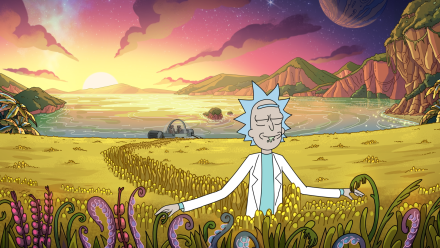

In [2]:
from PIL import Image
image_colored = Image.open ("/content/drive/MyDrive/AIML/rick_morty.png")
display ( image_colored )

In [3]:
print ( " Image Format : " , image_colored . format )
print ( " Image Size : " , image_colored . size )
print ( " Image Mode : " , image_colored . mode )

 Image Format :  PNG
 Image Size :  (440, 248)
 Image Mode :  RGBA


In [4]:
width,height = image_colored.size
channels = len(image_colored.getbands())
print(f"Image shape (RGB): ({height}, {width}, {channels})")
image_size_colored = width * height * 4
print(f"Image size (RGB): {image_size_colored}")

Image shape (RGB): (248, 440, 4)
Image size (RGB): 436480


In [5]:
 # Converting the Pillow image to a NumPy array
image_array_colored = np.array ( image_colored )
# Display the shape (height , width ,channels )
print (" Shape of the image array :", image_array_colored .shape )

 Shape of the image array : (248, 440, 4)


 Shape of the image array : (248, 440, 4)
[[ 97  98  98 ...  94  93  83]
 [100 100 101 ...  91  94  84]
 [103 103 103 ...  89  92  82]
 ...
 [ 34  39  42 ...  54  76  76]
 [ 21  41  42 ...  45  75  75]
 [ 16  41  40 ...  51  74  74]]


array([[ 97,  98,  98, ...,  94,  93,  83],
       [100, 100, 101, ...,  91,  94,  84],
       [103, 103, 103, ...,  89,  92,  82],
       ...,
       [ 34,  39,  42, ...,  54,  76,  76],
       [ 21,  41,  42, ...,  45,  75,  75],
       [ 16,  41,  40, ...,  51,  74,  74]], dtype=uint8)
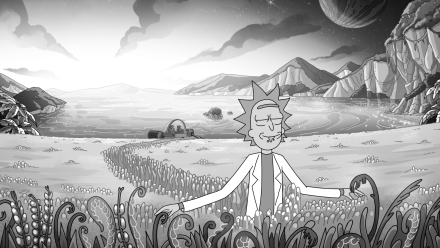

[[ 97  98  98 ...  94  93  83]
 [100 100 101 ...  91  94  84]
 [103 103 103 ...  89  92  82]
 ...
 [ 34  39  42 ...  54  76  76]
 [ 21  41  42 ...  45  75  75]
 [ 16  41  40 ...  51  74  74]]


array([[ 97,  98,  98, ...,  94,  93,  83],
       [100, 100, 101, ...,  91,  94,  84],
       [103, 103, 103, ...,  89,  92,  82],
       ...,
       [ 34,  39,  42, ...,  54,  76,  76],
       [ 21,  41,  42, ...,  45,  75,  75],
       [ 16,  41,  40, ...,  51,  74,  74]], dtype=uint8)
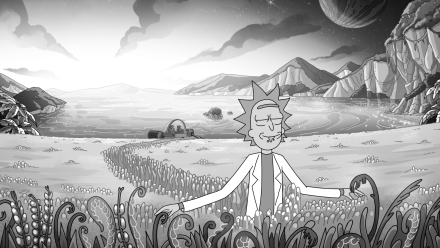

[[85 86 85 ... 47 46 45]
 [86 86 87 ... 46 46 44]
 [87 87 88 ... 46 46 44]
 ...
 [ 9  8  6 ... 15 16 16]
 [ 6  8  6 ... 11 15 15]
 [ 4  6  6 ... 14 15 15]]


array([[85, 86, 85, ..., 47, 46, 45],
       [86, 86, 87, ..., 46, 46, 44],
       [87, 87, 88, ..., 46, 46, 44],
       ...,
       [ 9,  8,  6, ..., 15, 16, 16],
       [ 6,  8,  6, ..., 11, 15, 15],
       [ 4,  6,  6, ..., 14, 15, 15]], dtype=uint8)
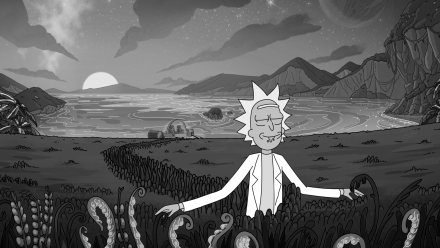

In [6]:
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape (height , width ,channels )
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored [: , : , 0] # Red channel
print ( red_channel )
display ( red_channel )
# For Green Channels
green_channel = image_array_colored [: , : , 0] # Greenchannel
print ( green_channel )
display ( green_channel )
# For Blue Channel :
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )
display ( blue_channel )

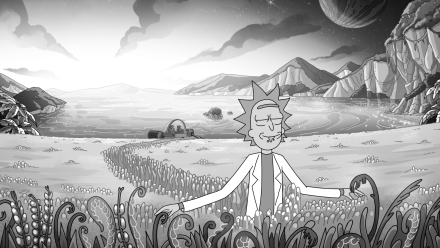

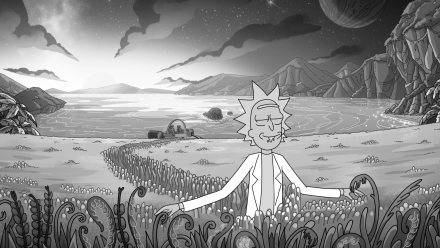

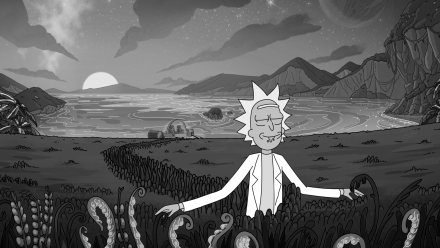

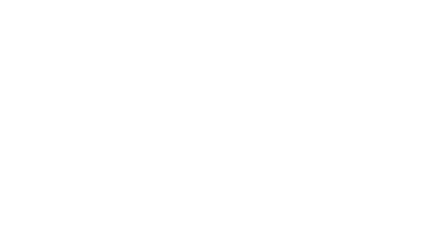

In [7]:
# Getting the R, G, and B channels
r, g, b, a = image_colored.split()
display(r)
display(g)
display (b)
display(a)

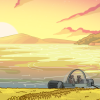

In [8]:
# Cropping box (left , upper , right , lower )
left = 100
upper = 50
right = 200
lower = 150
cropped_image = image_colored . crop (( left , upper , right ,lower ) )
display ( cropped_image )

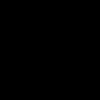

In [9]:
image_array = np . zeros ((100 , 100 , 3) , dtype = np . uint8 )
image_from_array = Image . fromarray ( image_array )
display(image_from_array)

In [10]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image.open ("/content/drive/MyDrive/AIML/rick_morty.png"). convert ("L")
image_array = np . array ( image )
height , width = image_array . shape
# Reshaping the image into a 2D array
data = image_array . reshape ( height , width )

In [11]:
mean = np . mean ( data , axis =0)
centered_data = data - mean

In [12]:
cov_matrix = np . cov ( centered_data , rowvar = False )

In [13]:
# eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

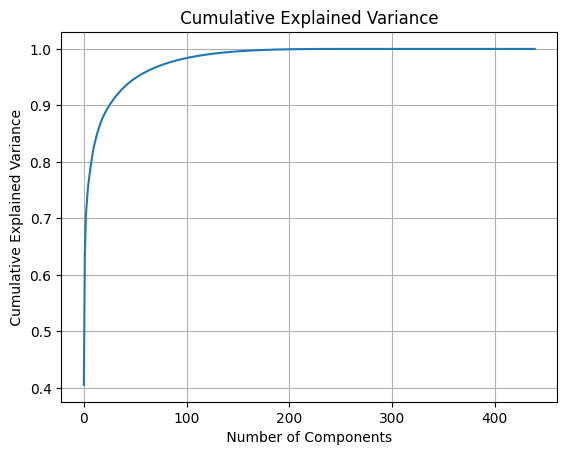

In [14]:
# variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [15]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [16]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [17]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

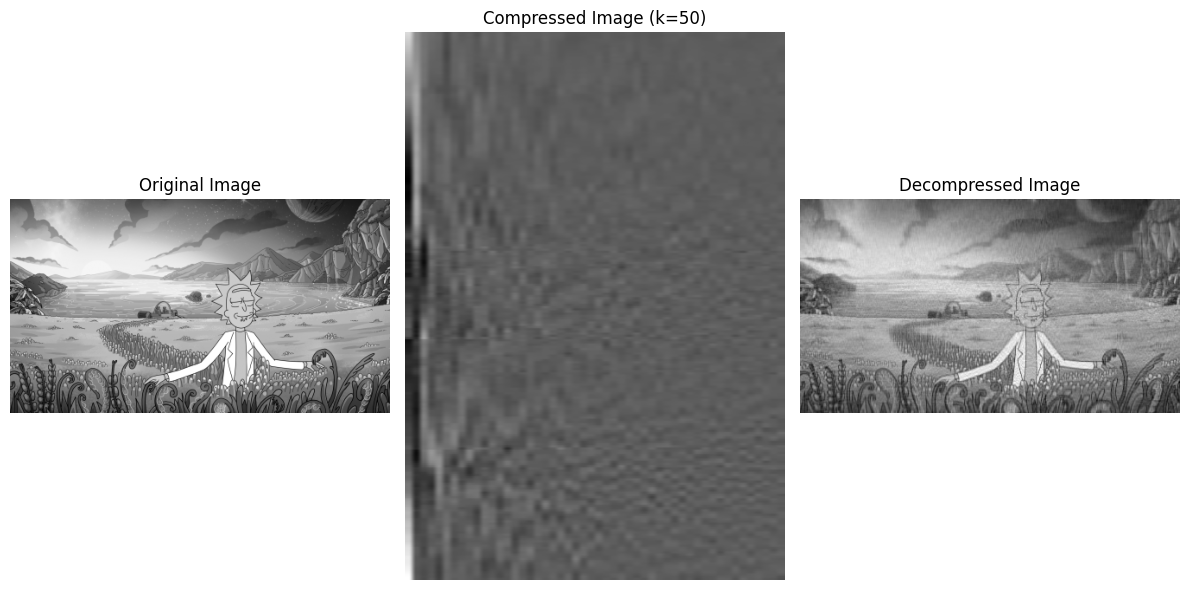

In [18]:
plt . figure ( figsize =(12 , 6) )
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title ("Original Image")
plt . axis ("off")

plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f"Compressed Image (k={k})")
plt . axis ("off")

plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title ("Decompressed Image")
plt . axis ("off")
plt . tight_layout ()
plt . show ()